# Xenium Breast 5K: cellAdmix Membrane Scoring

## Overview

This notebook starts from the provisional breast 5K annotations
generated in `breast_5k_annotation.Rmd`, then runs the main cellAdmix
workflow on the full Xenium bundle: fit molecule-level factors, infer
membrane-supported admixture patterns, remove molecules matching those
correction rules, and inspect the effect of cleanup.

The workflow is:

In [ ]:
ds <- cellAdmix(bundle_dir, output_dir = output_dir, annotation = cell_annotation)
fit <- ds$fit()

membrane_score <- fit$score_membrane()
membrane_rules <- membrane_score$rules()
membrane_correction <- membrane_score$correct(rules = membrane_rules)

## Inputs

Place the Xenium output bundle in a local folder named `data`. The
annotation notebook writes two compressed files under `annotations`:
cell-type labels in `annotation.csv.gz` and coarse tissue-domain labels
in `domain_annotation.csv.gz`. The output directory `out` is shared with
the annotation notebook so the count-only store can be reused and
upgraded to a full molecule store only when the fit requires it.

This 5K panel uses higher cell-complexity QC thresholds in the
annotation and cell-state diagnostic steps than the smaller pancreas
377-gene example: `min_molecules = 30` and `min_genes = 15`. With the
default lower thresholds, many very small low-complexity segmented
objects formed detached UMAP islands. These thresholds are practical
choices for this dataset, not universal defaults.

In [ ]:
bundle_dir <- "data"
output_dir <- "out"
nmf_variant <- Sys.getenv("CELLADMIX_NMF_VARIANT", "ls_nmf")
annotation_file <- file.path("annotations", "annotation.csv.gz")
domain_file <- file.path("annotations", "domain_annotation.csv.gz")

annotation <- read.csv(annotation_file, stringsAsFactors = FALSE)
domain_annotation <- read.csv(domain_file, stringsAsFactors = FALSE)

table(annotation$merged_annotation)


Ambiguous / low-quality              B / plasma             Endothelial 
                  47874                   25711                   18016 
             Epithelial        Fibroblast / CAF                 Myeloid 
                 166396                   11279                   82470 
                 T / NK 
                 118803 


     immune_rich tumor_epithelial 
          353299           117250 

The cell-type annotation is passed as a named vector. Cells labeled
`Ambiguous / low-quality` are retained in the side plots, but are
excluded from the active fit/scoring annotation so they are not treated
as a biological source or target class. The domain annotation is kept in
R memory for spatial plots and diagnostic DE comparisons; it is not used
to fit factors or score admixture.

In [ ]:
cell_annotation <- setNames(annotation$merged_annotation, annotation$cell_id)
cell_annotation <- cell_annotation[cell_annotation != "Ambiguous / low-quality"]

ds <- cellAdmix(bundle_dir, output_dir = output_dir, annotation = cell_annotation,
  num_threads = 10)

ds

cellAdmix dataset
  format: xenium 
  output cache: configured
  threads: 10 
  molecules: transcripts.parquet 
  cells: cells.parquet 
  annotation:manual (422675 cells, 6 labels)

## Fit Factors

The default fit uses inverse-square-root weighted KL NMF, automatic rank
based on the number of annotated cell types, multiple NMF starts, and
gene-loading molecule scoring. To render a direct KL comparison, set
`CELLADMIX_NMF_VARIANT=kl` before executing the notebook.

In [ ]:
fit <- ds$fit(nmf_variant = nmf_variant, verbose = TRUE)

Reusing cached run fit_manual_rank8_ls_nmf (parameters match)

cellAdmix fit
  run: fit_manual_rank8_ls_nmf 
  annotation: manual 
  rank: 8 
  NMF: ls_nmf 
  molecule scoring: gene_loadings 
  cells: 688099 
  transcripts: 82144903 

Top factor loadings are the first-pass interpretation of each factor.

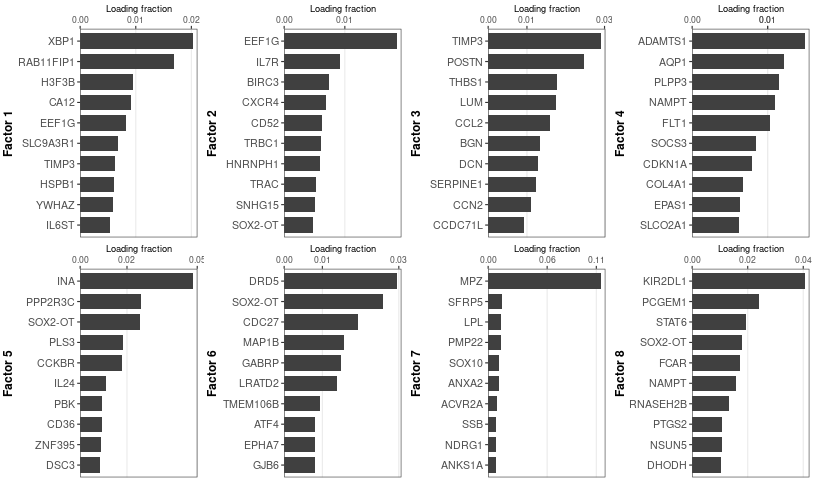

In [ ]:
fit$plot_loadings()

The stability plot summarizes how reproducible the factors were across
NMF starts. High-importance, high-stability factors are usually easiest
to interpret.

The stability plot shows the matched gene-ownership correlation of each
factor across independent NMF restarts (near zero for unrelated factors,
above 0.3 for reproducibly re-found ones). Factor importance (the
x-axis, echoed by dot size) is the share of all assigned molecules that
carry the factor’s label, so large dots mark factors that dominate the
tissue-wide signal.

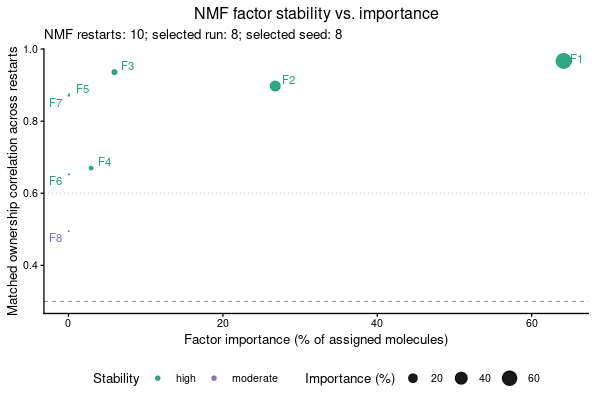

In [ ]:
fit$plot_stability()

## Tissue Context

For the side visualizations below, merge cell-level factor summaries
with the provisional cell-type and domain annotations.

In [ ]:
cell_factors <- fit$cell_factors()
cell_spatial <- merge(cell_factors,
  annotation[, c("cell_id", "merged_annotation", "cluster_label")],
  by = "cell_id", all.x = FALSE, sort = FALSE)
cell_spatial <- merge(cell_spatial,
  domain_annotation[, c("cell_id", "domain_label")],
  by = "cell_id", all.x = FALSE, sort = FALSE)
cell_spatial$domain_label <- factor(cell_spatial$domain_label,
  levels = c("immune_rich", "tumor_epithelial"))

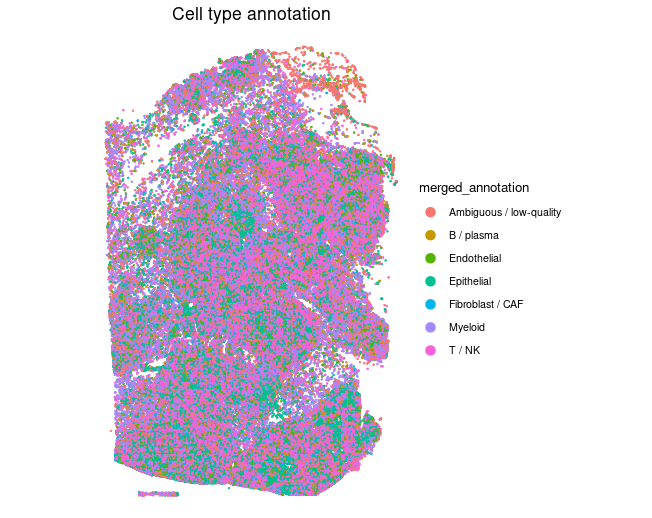

In [ ]:
celladmix_plot_spatial(cell_spatial, color_by = "merged_annotation",
  point_size = 0.06) +
  ggtitle("Cell type annotation")

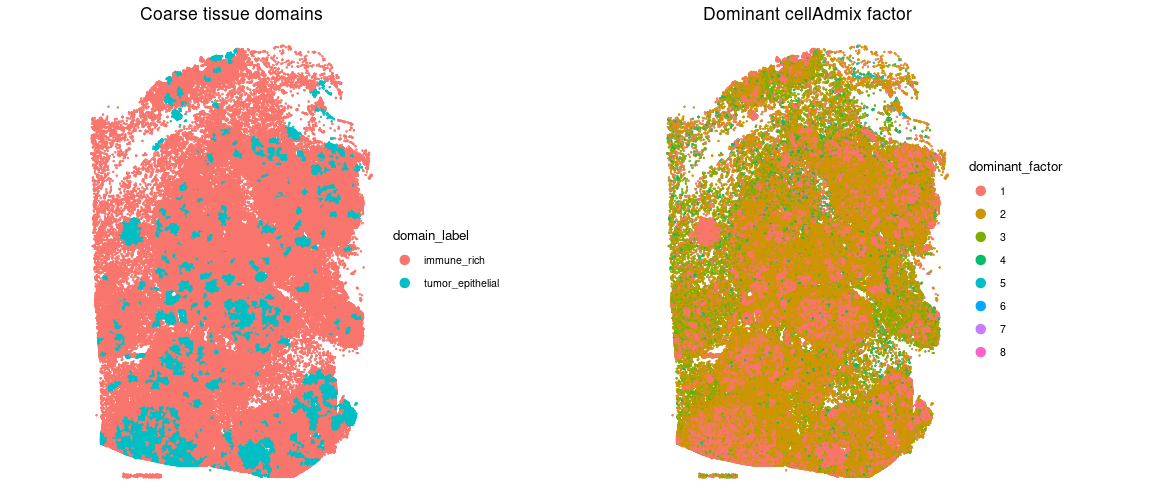

In [ ]:
cowplot::plot_grid(plotlist = list(
  celladmix_plot_spatial(cell_spatial, color_by = "domain_label",
    point_size = 0.06) +
    ggtitle("Coarse tissue domains"),
  celladmix_plot_spatial(cell_spatial, color_by = "dominant_factor",
    point_size = 0.06) +
    ggtitle("Dominant cellAdmix factor")
), ncol = 2, align = "hv", axis = "tblr")

## Diagnostic Setup

Correction is run for all annotated cell types. To keep the follow-up
plots readable, the diagnostic DE panels focus on stromal/vascular cells
that are present in both coarse domains. The marker sets highlight
likely source signatures that may appear as admixture in those target
cells.

In [ ]:
diagnostic_cell_types <- c("Fibroblast / CAF", "Endothelial")

epithelial_tumor_markers <- c("EPCAM", "KRT8", "KRT18", "KRT19", "MUC1",
  "GATA3", "CA12", "XBP1", "ERBB2")
lymphoid_myeloid_markers <- c("TRAC", "TRBC1", "CD3D", "CD3E", "CD8A",
  "IL7R", "MS4A1", "CD79A", "AIF1", "C1QC", "MS4A6A", "ITGAX")
source_marker_sets <- list(
  "epithelial/tumor source" = epithelial_tumor_markers,
  "immune source" = lymphoid_myeloid_markers
)

The baseline DE comparison contrasts the tumor-epithelial domain against
the immune-rich domain within each diagnostic cell type. This is an
illustrative diagnostic, not a curated biological benchmark.

In [ ]:
original_counts <- fit$counts()
diagnostic_de_original <- celladmix_de_by_group(original_counts, cell_spatial,
  subset_by = "merged_annotation", subsets = diagnostic_cell_types,
  group_by = "domain_label", contrast = c("tumor_epithelial", "immune_rich"))

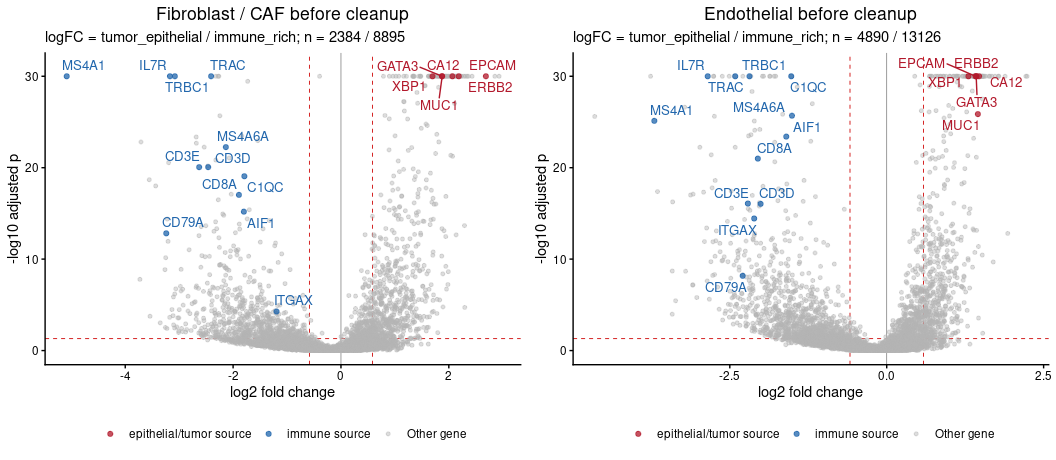

In [ ]:
baseline_volcano_plots <- lapply(diagnostic_cell_types, function(target_type) {
  de <- diagnostic_de_original[[target_type]]
  celladmix_plot_volcano(de, markers = source_marker_sets,
    title = paste(target_type, "before cleanup"),
    subtitle = sprintf("logFC = tumor_epithelial / immune_rich; n = %d / %d",
      unique(de$n_group_a), unique(de$n_group_b)))
})
cowplot::plot_grid(plotlist = baseline_volcano_plots,
  ncol = length(baseline_volcano_plots), align = "hv", axis = "tblr")

## Membrane Scoring

Membrane scoring asks whether target-cell molecules assigned to a factor
are enriched along membrane-stain paths facing a candidate source cell
type.

In [ ]:
p_thresh <- 0.1
score_pairs_width <- 9.6
score_pairs_height <- max(6, ceiling(fit$rank / 2) * 4.9)

In [ ]:
membrane_score <- fit$score_membrane()

The factor annotation identifies likely factor source cell types and
significant target cell types. Correction rules say which factor/target
combinations will be removed.

In [ ]:
membrane_annotation <- membrane_score$annotation(p_thresh = p_thresh)
membrane_rules <- membrane_score$rules(p_thresh = p_thresh)

head(membrane_rules[, c("factor", "source_cell_type", "target_cell_type", "p_value")])

  factor source_cell_type target_cell_type      p_value
1      1       Epithelial       B / plasma 0.0336905688
2      1       Epithelial          Myeloid 0.0716527150
3      1       Epithelial           T / NK 0.0262456573
4      2           T / NK       B / plasma 0.0080617738
5      2           T / NK      Endothelial 0.0891373113
6      2           T / NK       Epithelial 0.0005570023

The heatmap shows factor-by-cell-type evidence, with symbols marking
inferred source and cleanup target calls.

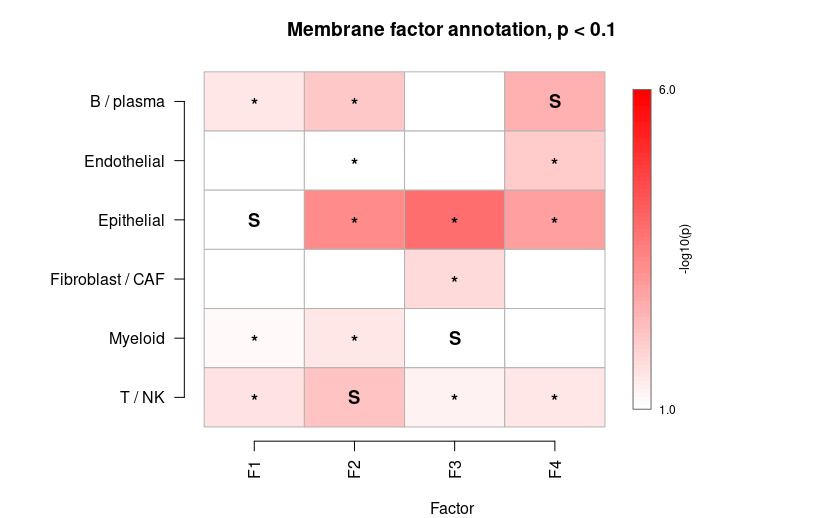

In [ ]:
membrane_score$plot_heatmap(p_thresh = p_thresh)

The pair plots show one factor at a time. The top margin shows source
evidence; the main heatmap shows target significance for source-target
cell-type pairs.

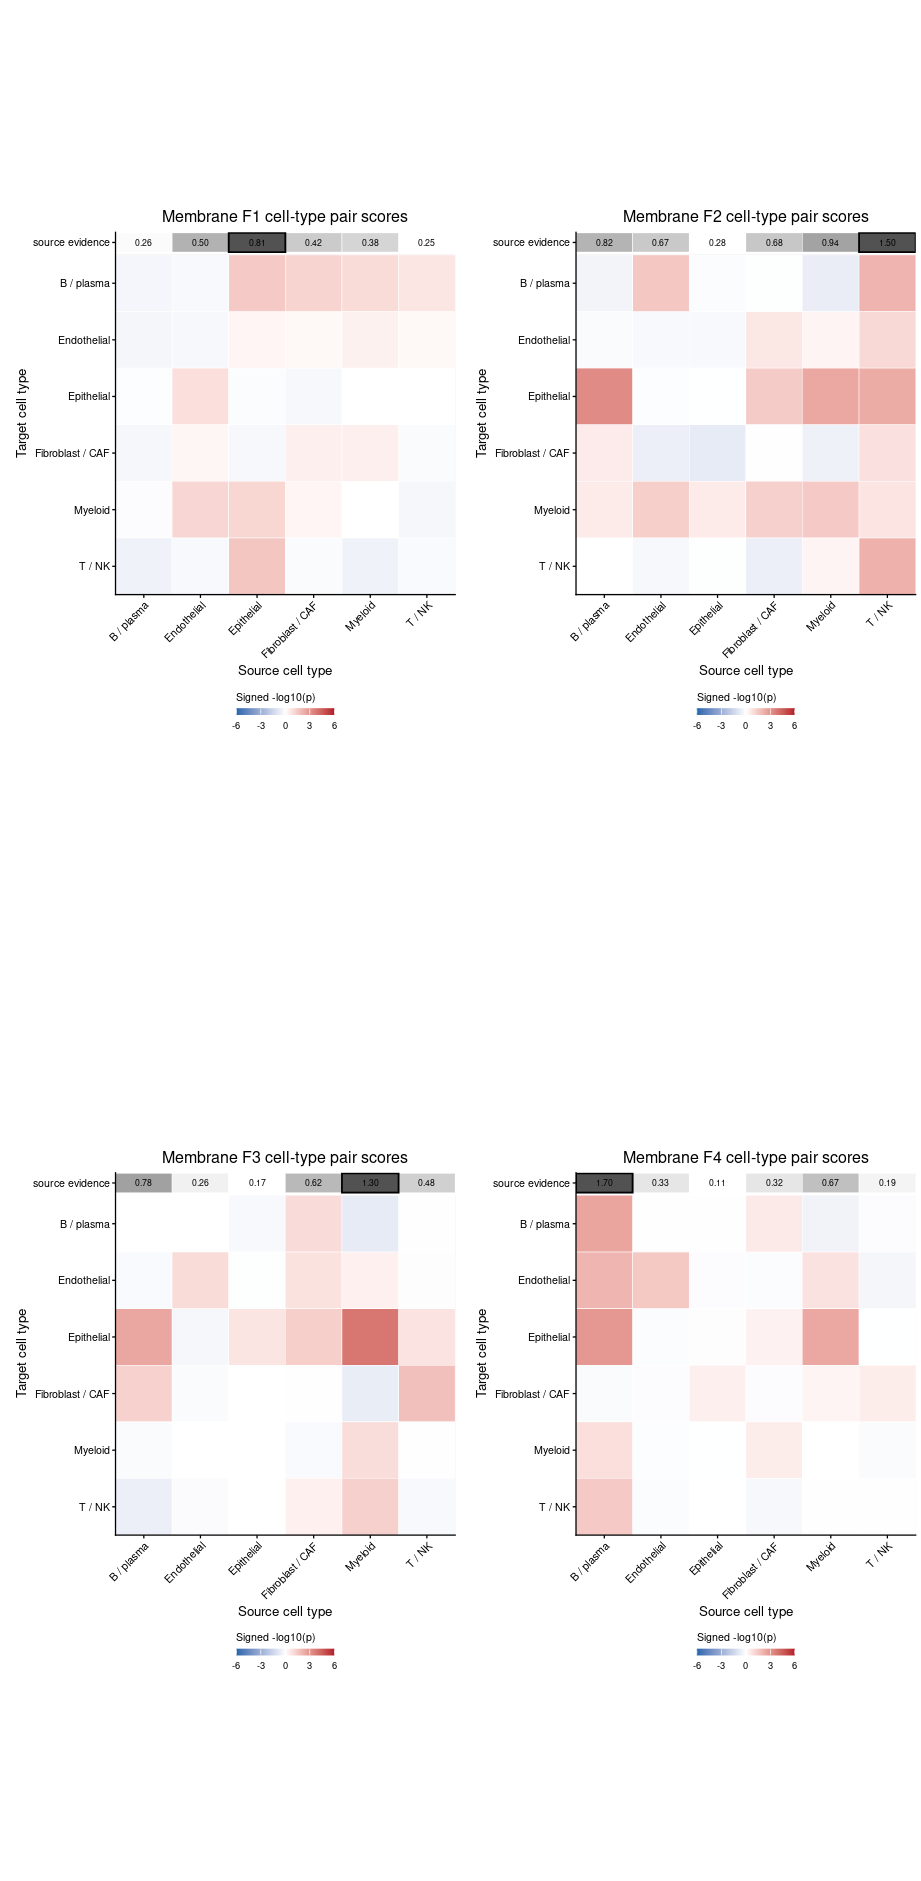

In [ ]:
membrane_score$plot_pairs()

## Example Cells

These examples show the molecule-level interpretation for selected
diagnostic cells before cleanup. The examples are chosen from cells with
strong rule-supported membrane-score evidence. Molecule colors show the
native factor set in blue, the top putative admixture factor in red, and
other non-native factors in orange. Source-marker molecules are drawn
slightly larger.

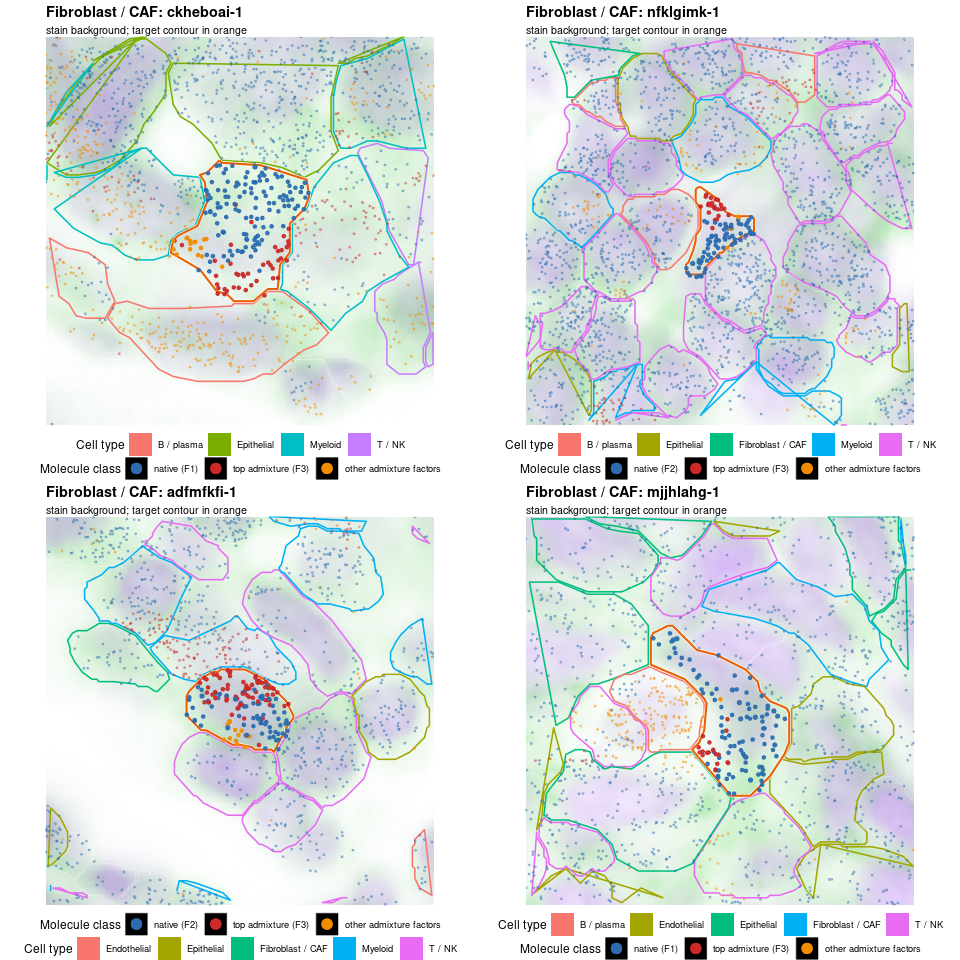

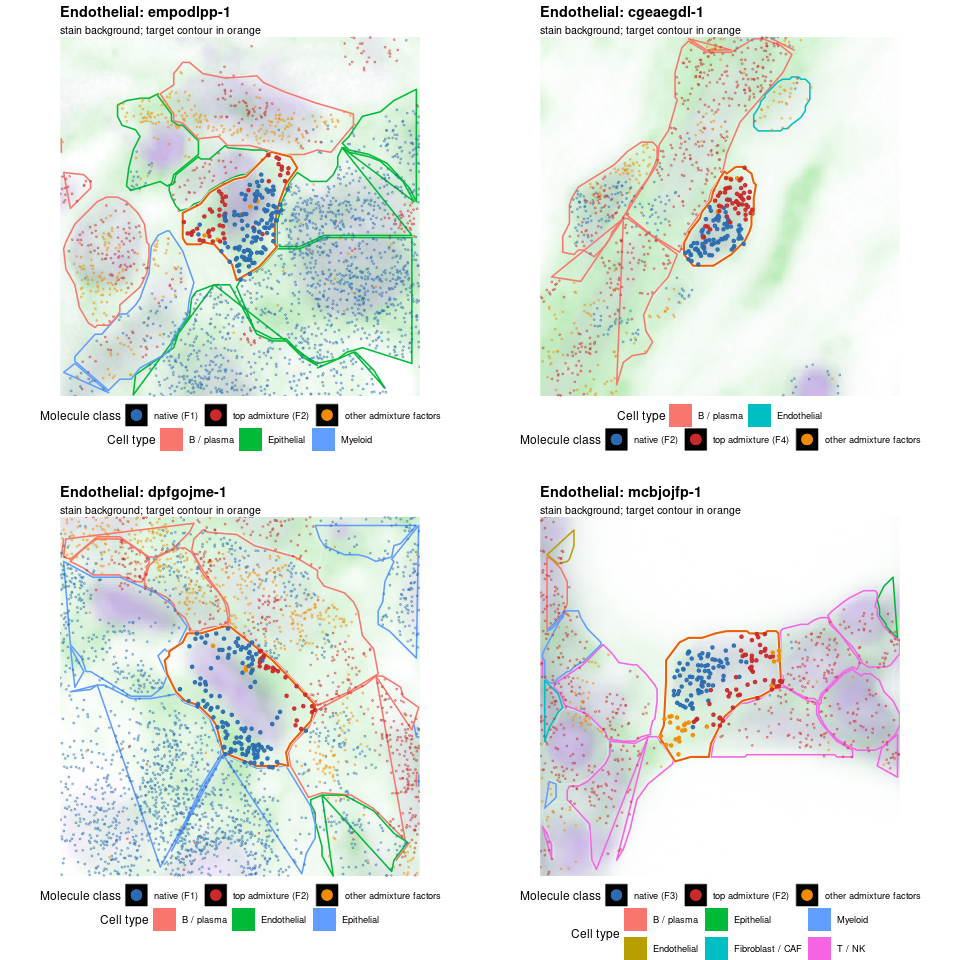

In [ ]:
example_cells <- membrane_score$examples(rules = membrane_rules,
  score_annotation = membrane_annotation, cell_data = cell_spatial,
  targets = diagnostic_cell_types, n_per_target = 4)

for (cell_type in diagnostic_cell_types) {
  type_examples <- example_cells[example_cells$target_cell_type == cell_type, , drop = FALSE]
  print(membrane_score$plot_examples(type_examples,
    score_annotation = membrane_annotation, cell_data = cell_spatial,
    markers = unique(unlist(source_marker_sets)), ncol = 2))
}

## Cleanup

Apply all membrane-derived correction rules across all annotated cell
types. The corrected counts are then used for diagnostic plots.

In [ ]:
membrane_correction <- membrane_score$correct(rules = membrane_rules,
  name = "membrane_clean")
membrane_counts <- membrane_correction$counts()

membrane_correction$summary()

         cell_type n_cells n_modified_cells fraction_cells_modified
1              all  688099           328767               0.4777903
2       B / plasma   25711                0               0.0000000
3      Endothelial   18016            13818               0.7669849
4       Epithelial  166396           157088               0.9440612
5 Fibroblast / CAF   11279             3976               0.3525135
6          Myeloid   82470            60929               0.7388020
7           T / NK  118803            92956               0.7824382
8          unknown  265424                0               0.0000000
  molecules_before molecules_after molecules_removed fraction_molecules_removed
1         82144903        74213313           7931590                 0.09655608
2          3831465         3831465                 0                 0.00000000
3          1275509          797528            477981                 0.37473746
4         50582711        46491275           4091436                

In [ ]:
membrane_de <- celladmix_de_by_group(membrane_counts, cell_spatial,
  subset_by = "merged_annotation", subsets = diagnostic_cell_types,
  group_by = "domain_label", contrast = c("tumor_epithelial", "immune_rich"))

## Cleanup Diagnostics

This boxplot summarizes how many molecules were removed from modified
cells.

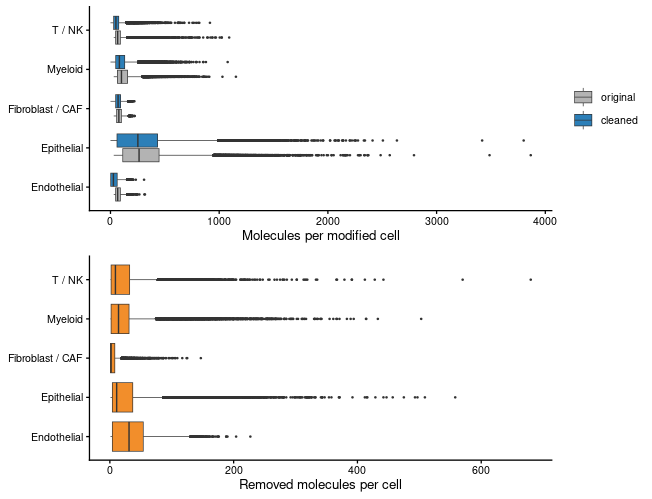

In [ ]:
membrane_correction$plot_removed_molecules()

Marker-expression plots show how source-marker expression changed after
cleanup in the two diagnostic cell types.

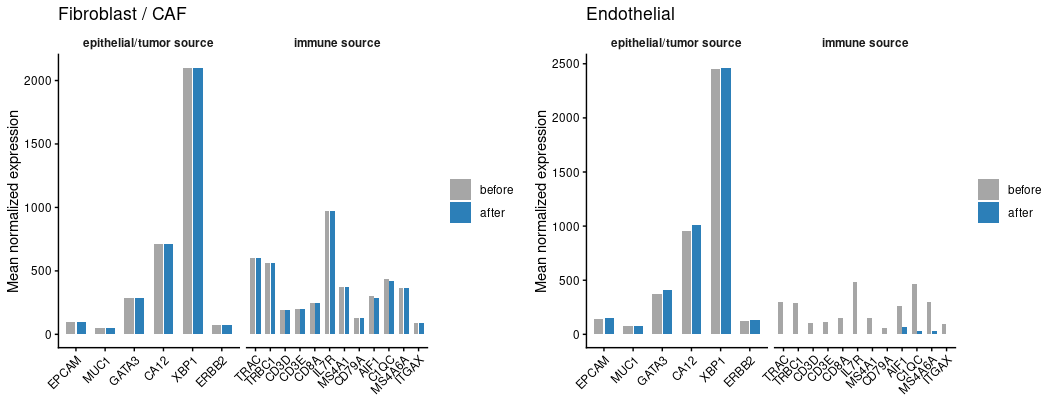

In [ ]:
plots <- lapply(diagnostic_cell_types, function(cell_type) {
  cells <- cell_spatial$cell_id[cell_spatial$merged_annotation == cell_type]
  celladmix_plot_marker_expression(original_counts, membrane_counts,
    cells = cells, markers = source_marker_sets) +
    ggtitle(cell_type)
})
cowplot::plot_grid(plotlist = plots, ncol = length(plots), align = "hv", axis = "tblr")

Volcano plots show the diagnostic domain comparison before and after
cleanup.

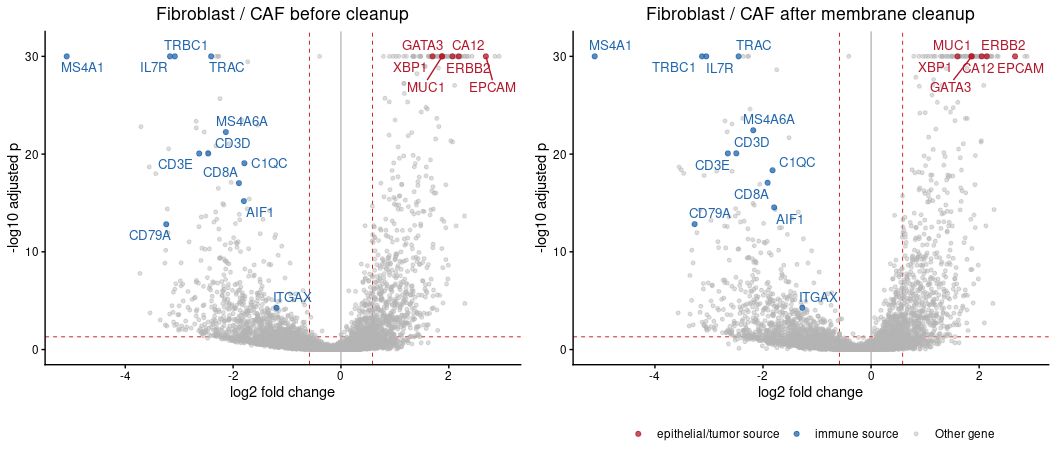

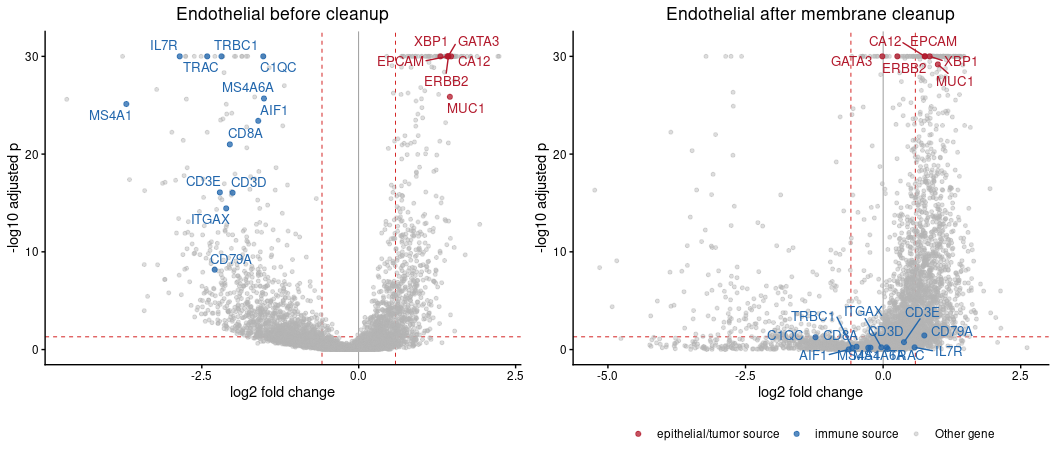

In [ ]:
for (target_type in diagnostic_cell_types) {
  p_before <- celladmix_plot_volcano(diagnostic_de_original[[target_type]],
    markers = source_marker_sets, title = paste(target_type, "before cleanup")) +
    theme(legend.position = "none")
  p_after <- celladmix_plot_volcano(membrane_de[[target_type]],
    markers = source_marker_sets, title = paste(target_type, "after membrane cleanup"))
  print(cowplot::plot_grid(plotlist = list(p_before, p_after),
    ncol = 2, align = "hv", axis = "tblr"))
}

The p-value shift plots compare signed DE significance before and after
cleanup. Genes below the diagonal are less significant after correction.

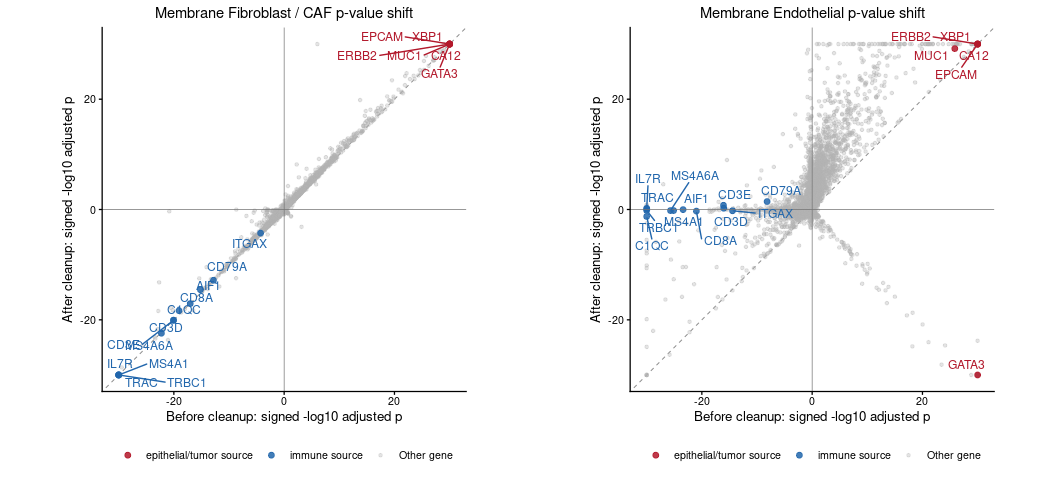

In [ ]:
plots <- lapply(diagnostic_cell_types, function(target_type) {
  celladmix_plot_de_shift(diagnostic_de_original[[target_type]], membrane_de[[target_type]],
    markers = source_marker_sets, title = paste("Membrane", target_type, "p-value shift"))
})
cowplot::plot_grid(plotlist = plots, ncol = length(plots), align = "hv", axis = "tblr")

## Cell-State UMAP Before and After Cleanup

As a compact global diagnostic, compute cell-state UMAPs from sparse
cell-level counts before and after cleanup. The two UMAPs are
independent embeddings, so the exact coordinates are not meant to align;
the comparison asks whether the corrected counts produce clearer
annotation separation.

In [ ]:
state_cells_max <- 5000
original_state <- ds$cell_state_umap(cells_max = state_cells_max,
  min_molecules = 30, min_genes = 15, verbose = TRUE)

[INFO 22:44:33 +0.003s] Reused compatible Xenium input store (0.000s)
[INFO 22:44:33 +0.003s] Built Xenium input store: 82144903 molecules, 688099 cells (0.003s)
[INFO 22:44:36 +2.565s] Loaded input-store cell-gene counts: 688099 cells (2.565s)
[INFO 22:44:36 +2.699s] Indexed cell counts: 470549 eligible cells (min_molecules=30, min_genes=15) (0.134s)
[INFO 22:44:36 +2.940s] Selected clustering cells: 5000 cells (0.241s)
[INFO 22:44:36 +2.963s] Loaded sparse cell-gene counts: 776043 non-zero entries (0.023s)
[INFO 22:44:36 +2.987s] Selected variable genes: 1000 genes (0.024s)
[INFO 22:44:36 +3.044s] Materialized dense clustering matrix: 1000 x 5000 (0.057s)
[INFO 22:44:37 +3.967s] Computed cell PCA: 30 x 5000 (0.922s)
[INFO 22:44:37 +4.285s] Built HNSW cell KNN graph: 75000 directed edges using 10 thread(s); reusing 15 cosine-distance neighbors for UMAP (0.318s)
[INFO 22:44:37 +4.296s] Ran Louvain clustering (0.011s)
[INFO 22:44:37 +4.339s] Initialized UMAP layout (0.043s)
[INFO 22:44:

[INFO 22:45:07 +22.867s] Loaded run cell-gene counts: 688099 cells (22.867s)
[INFO 22:45:07 +23.073s] Indexed cell counts: 396146 eligible cells (min_molecules=30, min_genes=15) (0.206s)
[INFO 22:45:07 +23.279s] Selected clustering cells: 5000 cells (0.206s)
[INFO 22:45:07 +23.323s] Loaded sparse cell-gene counts: 788314 non-zero entries (0.044s)
[INFO 22:45:07 +23.346s] Selected variable genes: 1000 genes (0.023s)
[INFO 22:45:07 +23.403s] Materialized dense clustering matrix: 1000 x 5000 (0.057s)
[INFO 22:45:08 +24.416s] Computed cell PCA: 30 x 5000 (1.013s)
[INFO 22:45:09 +24.699s] Built HNSW cell KNN graph: 75000 directed edges using 10 thread(s); reusing 15 cosine-distance neighbors for UMAP (0.284s)
[INFO 22:45:09 +24.715s] Ran Louvain clustering (0.016s)
[INFO 22:45:09 +24.758s] Initialized UMAP layout (0.043s)
[INFO 22:45:14 +29.717s] Optimized UMAP layout with parallel optimization (4.959s)
[INFO 22:45:14 +29.717s] Computed cell UMAP (5.002s)
[INFO 22:45:14 +29.721s] Assembled 

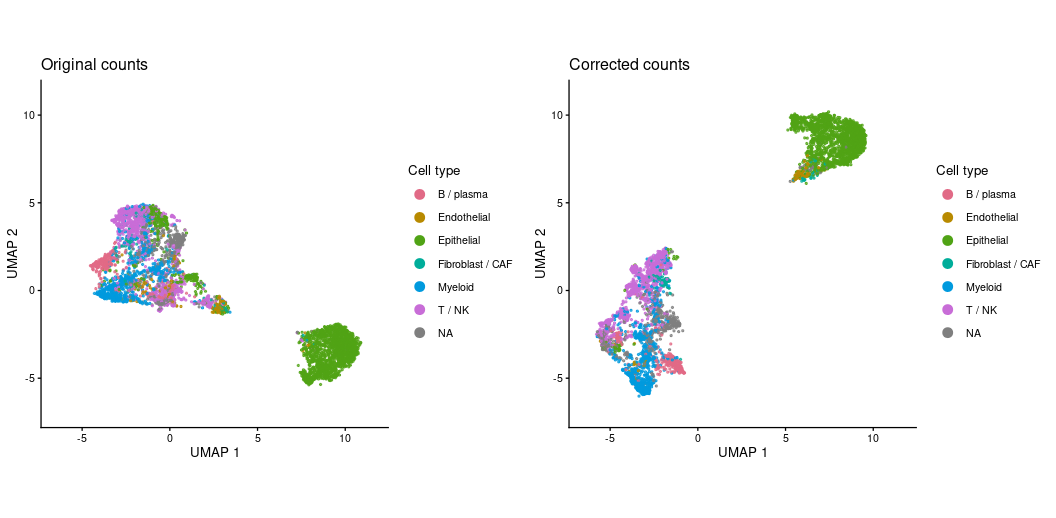

In [ ]:
state_umap_limits <- function(...) {
  frames <- list(...)
  x <- unlist(lapply(frames, `[[`, "umap_1"))
  y <- unlist(lapply(frames, `[[`, "umap_2"))
  span <- max(diff(range(x, na.rm = TRUE)), diff(range(y, na.rm = TRUE)))
  xmid <- mean(range(x, na.rm = TRUE))
  ymid <- mean(range(y, na.rm = TRUE))
  pad <- span * 0.04
  list(xlim = xmid + c(-1, 1) * (span / 2 + pad),
    ylim = ymid + c(-1, 1) * (span / 2 + pad))
}

plot_state_umap <- function(df, title, limits) {
  ggplot(df, aes(umap_1, umap_2, color = cell_type)) +
    geom_point(size = 0.55, alpha = 0.75) +
    coord_equal(xlim = limits$xlim, ylim = limits$ylim) +
    scale_color_manual(values = cell_type_palette, drop = FALSE) +
    labs(title = title, x = "UMAP 1", y = "UMAP 2", color = "Cell type") +
    theme_classic(base_size = 10) +
    guides(color = guide_legend(override.aes = list(size = 3.2, alpha = 1))) +
    theme(legend.position = "right")
}

limits <- state_umap_limits(original_state, corrected_state)
cowplot::plot_grid(plotlist = list(
  plot_state_umap(original_state, "Original counts", limits),
  plot_state_umap(corrected_state, "Corrected counts", limits)
), ncol = 2, align = "hv", axis = "tblr")